# 40 — Complete MotionSense-AI ML Project

## Goal
To run the full machine learning workflow from dataset loading to final evaluation.

## Research Question
Can smartphone sensor data predict human activity using a complete machine learning pipeline?

## MotionSense-AI Pipeline

```text
Raw Data → Clean Data → Features → Visualization → Machine Learning → Prediction
```



## Complete project workflow

This final notebook combines all the steps performed so far into one clean pipeline:

```text
Load Data → Select Features → Split Data → Train Model → Predict → Evaluate → Save Model
```

In [1]:
from pathlib import Path
import pandas as pd

# DATA_DIR points to the shared data folder for this project.
DATA_DIR = Path("../data")
PROCESSED_DIR = DATA_DIR / "processed"
ML_READY_PATH = PROCESSED_DIR / "motionsense_ml_ready.csv"

import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

# 1. Load the ML-ready dataset.
df = pd.read_csv(ML_READY_PATH)

# 2. Select a simple feature set.
feature_columns = [
    "acc_x", "acc_y", "acc_z",
    "gyro_x", "gyro_y", "gyro_z",
    "acc_magnitude", "gyro_magnitude"
]
X = df[feature_columns]
y = df["activity"]

# 3. Split the data.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 4. Train the model.
model = RandomForestClassifier(n_estimators=50, random_state=42)
model.fit(X_train, y_train)

# 5. Make predictions.
predictions = model.predict(X_test)

# 6. Evaluate accuracy.
accuracy = accuracy_score(y_test, predictions)
print(f"Final accuracy: {accuracy:.2%}")

Final accuracy: 99.07%


In [2]:
# Show detailed performance by activity.
print(classification_report(y_test, predictions))

                    precision    recall  f1-score   support

            Laying       1.00      1.00      1.00       144
           Sitting       1.00      1.00      1.00       144
          Standing       1.00      1.00      1.00       144
           Walking       0.95      1.00      0.97       144
Walking Downstairs       1.00      0.98      0.99       144
  Walking Upstairs       1.00      0.97      0.98       144

          accuracy                           0.99       864
         macro avg       0.99      0.99      0.99       864
      weighted avg       0.99      0.99      0.99       864



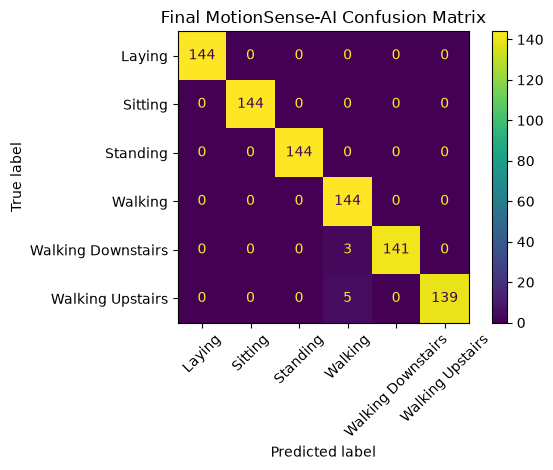

In [3]:
# Visualize prediction mistakes.
ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    xticks_rotation=45
)
plt.title("Final MotionSense-AI Confusion Matrix")
plt.tight_layout()
plt.show()

In [4]:
# Save the final model.
FINAL_MODEL_PATH = PROCESSED_DIR / "motionsense_final_model.joblib"
joblib.dump(model, FINAL_MODEL_PATH)

print("Final model saved to:", FINAL_MODEL_PATH)

Final model saved to: ..\data\processed\motionsense_final_model.joblib


## Final research conclusion

The model uses smartphone sensor measurements and engineered motion features to predict the activity label. The final accuracy and class-level metrics show how well the model learned patterns from the dataset.

This completes the first full MotionSense-AI machine learning pipeline.